# 13 · Symbolic mathematics with SymPy

Numerical methods give numbers; **symbolic** mathematics gives formulas. SymPy does algebra and
calculus exactly, like a tireless and careful colleague with pencil and paper. Engineers use it to

- derive formulas (and avoid algebra slips),
- derive and analyse *numerical methods* - e.g. the error of a finite-difference formula,
- produce exact reference results to test numerical code,
- generate derivatives (Jacobians) automatically and turn them into fast NumPy functions.

**Problem.** Derive the deflection of a cantilever beam under a uniform load, check the classic
handbook result, and then use SymPy to derive - and check - numerical methods from earlier notebooks.

**What you will learn**

- compute derivatives, integrals, series and exact solutions of ODEs with SymPy
- derive an engineering formula (beam deflection) symbolically
- derive finite-difference and quadrature formulas together with their error terms
- turn symbolic results into NumPy functions and use them to test numerical code

**Before you start:** notebooks 00, 05 and 06; Taylor series  ·  **Time:** about 60 min

Run the cells in order (Shift + Enter). Then change the numbers and run them again - that is how the
ideas sink in.

In [1]:
try:                      # on Google Colab (or anywhere engmath is missing): install it from GitHub
    import engmath
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engmath"], check=True)
import numpy as np
import matplotlib.pyplot as plt
import engmath
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")
import sympy as sp

## Symbols, expressions and calculus

In [2]:
x, t = sp.symbols("x t")
expr = sp.exp(x) * sp.sin(x)
print("derivative:        ", sp.diff(expr, x))
print("antiderivative:    ", sp.integrate(expr, x))
print("Taylor series:     ", sp.series(expr, x, 0, 5))
print("Gaussian integral: ", sp.integrate(sp.exp(-x**2), (x, -sp.oo, sp.oo)))
print("integral of x^2 sin x on [0, pi]:", sp.integrate(x**2 * sp.sin(x), (x, 0, sp.pi)))

derivative:         exp(x)*sin(x) + exp(x)*cos(x)
antiderivative:     exp(x)*sin(x)/2 - exp(x)*cos(x)/2
Taylor series:      x + x**2 + x**3/3 + O(x**5)


Gaussian integral:  sqrt(pi)
integral of x^2 sin x on [0, pi]: -4 + pi**2


Results are exact: $\sqrt{\pi}$ stays `sqrt(pi)`, not 1.7724538509.

## Deriving a formula: deflection of a cantilever
A beam clamped at $x = 0$ and free at $x = L$ carries a uniform load $w$ (N/m). Euler-Bernoulli beam
theory gives $EI\,v^{(4)} = w$, with $v = v' = 0$ at the clamp and zero bending moment and shear force at
the free end, $v''(L) = v^{(3)}(L) = 0$.

In [3]:
L, EI, w = sp.symbols("L EI w", positive=True)
v = sp.Function("v")
bcs = {v(0): 0, v(x).diff(x).subs(x, 0): 0, v(x).diff(x, 2).subs(x, L): 0, v(x).diff(x, 3).subs(x, L): 0}
deflection = sp.factor(sp.dsolve(sp.Eq(EI * v(x).diff(x, 4), w), v(x), ics=bcs).rhs)
tip = sp.simplify(deflection.subs(x, L))
print("v(x) =", deflection)
print("tip deflection =", tip)

v(x) = w*x**2*(6*L**2 - 4*L*x + x**2)/(24*EI)
tip deflection = L**4*w/(8*EI)


SymPy reproduces the handbook formula $v_{tip} = wL^4/(8EI)$. `lambdify` turns the symbolic result into
an ordinary NumPy function - here for a 2 m steel cantilever (rectangular 50 × 100 mm section) carrying
2 kN/m:

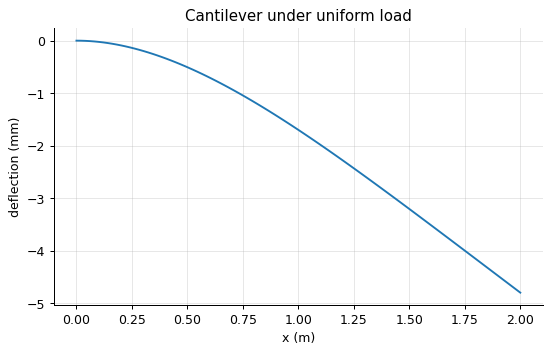

tip deflection 4.800 mm


In [4]:
v_num = sp.lambdify((x, L, EI, w), deflection, "numpy")
E, b, hgt = 200e9, 0.05, 0.10
I = b * hgt**3 / 12
xx = np.linspace(0, 2, 100)
plt.plot(xx, -v_num(xx, 2.0, E*I, 2000.0) * 1000)
plt.xlabel("x (m)"); plt.ylabel("deflection (mm)"); plt.title("Cantilever under uniform load"); plt.show()
print(f"tip deflection {v_num(2.0, 2.0, E*I, 2000.0)*1000:.3f} mm")

## Inside the algorithm: what `lambdify` produces
`lambdify` writes an ordinary Python function whose body is the formula in NumPy syntax - you can read
the generated code:

In [5]:
import inspect
print(inspect.getsource(v_num))

def _lambdifygenerated(x, L, EI, w):
    return (1/24)*w*x**2*(6*L**2 - 4*L*x + x**2)/EI



## Deriving numerical methods: finite differences and their errors
Notebook 06 used a 3-point derivative formula for **unequal** spacing. Where does it come from, and how
accurate is it? Fit the parabola through three points and differentiate it at the middle one:

In [6]:
h1, h2 = sp.symbols("h1 h2", positive=True)
f0, f1, f2 = sp.symbols("f_0 f_1 f_2")
parabola = sp.interpolate([(-h1, f0), (0, f1), (h2, f2)], t)
derivative_formula = sp.expand(sp.diff(parabola, t).subs(t, 0))
for fi in (f0, f1, f2):
    print(fi, "coefficient:", sp.factor(derivative_formula.coeff(fi)))

f_0 coefficient: -h2/(h1*(h1 + h2))
f_1 coefficient: -(h1 - h2)/(h1*h2)
f_2 coefficient: h1/(h2*(h1 + h2))


These are exactly the coefficients used in notebook 06. Now the **error**: replace $f_0, f_1, f_2$ by
Taylor series of a smooth function about the middle point, written with its derivatives
$F_0 = f,\ F_1 = f',\ F_2 = f'', \ldots$

In [7]:
F = sp.symbols("F0:6")          # F0 = f, F1 = f', F2 = f'', ...
taylor = lambda s: sum(F[j] * s**j / sp.factorial(j) for j in range(6))
error = sp.expand(derivative_formula.subs({f0: taylor(-h1), f1: taylor(0), f2: taylor(h2)}) - F[1])
leading = sp.factor(error.coeff(F[3]) * F[3])
print("leading error term:", leading)
print("with equal spacing:", sp.factor(leading.subs({h1: sp.Symbol("h"), h2: sp.Symbol("h")})))

leading error term: F3*h1*h2/6
with equal spacing: F3*h**2/6


The error is proportional to $h_1 h_2\, F_3$ (the third derivative): **second order** for any spacing,
as the convergence study of notebook 06 found. For equal spacing it becomes the familiar $h^2 F_3/6$:
the central difference overestimates the slope where the third derivative is positive.

The same trick gives Simpson's rule: integrate the parabola through three equally spaced points.

In [8]:
h = sp.Symbol("h", positive=True)
simpson = sp.integrate(sp.interpolate([(-h, f0), (0, f1), (h, f2)], t), (t, -h, h))
print("Simpson's rule:", sp.factor(simpson))

Simpson's rule: h*(f_0 + 4*f_1 + f_2)/3


## Symbolic Jacobians for Newton's method
Newton's method for systems (notebook 14) needs the Jacobian matrix. SymPy computes it exactly and
`lambdify` turns it into a fast function - no finite-difference errors.

In [9]:
X, Y = sp.symbols("X Y")
Fsym = sp.Matrix([X**2 + Y**2 - 4, sp.exp(X) + Y - 1])
Jsym = Fsym.jacobian([X, Y])
print("J =", Jsym)
F_fun = sp.lambdify([(X, Y)], list(Fsym), "numpy")
J_fun = sp.lambdify([(X, Y)], Jsym, "numpy")
from engmath import nonlinear
sol = nonlinear.newton_system(F_fun, [1.0, -1.5], J=J_fun)
print(sol, "  residual:", np.round(F_fun(sol.x), 14))

J = Matrix([[2*X, 2*Y], [exp(X), 1]])
x = [ 1.00416874 -1.72963729] (converged in 4 iterations)   residual: [0. 0.]


## Exact results as test cases for numerical code
A symbolic result is a perfect reference. How fast does Simpson's rule converge on
$\int_0^\pi x^2\sin x\,dx$, whose exact value SymPy gave above as $\pi^2 - 4$?

In [10]:
from engmath import integrate
exact = float(sp.integrate(x**2 * sp.sin(x), (x, 0, sp.pi)))
g = lambda s: s**2 * np.sin(s)
for n in (4, 8, 16, 32):
    err = abs(integrate.composite(g, 0, np.pi, n, "simpson") - exact)
    print(f"n = {n:>2}: error {err:.2e}")

n =  4: error 1.00e-02
n =  8: error 3.58e-04
n = 16: error 1.87e-05
n = 32: error 1.12e-06


Each doubling of $n$ cuts the error about 16-fold: fourth order, as theory predicts.

## Limits of symbolic computation
Not everything has a formula. Polynomials of degree five and higher generally have **no** solution in
radicals (Abel-Ruffini theorem); SymPy then returns implicit roots, and numbers must come from a
numerical method:

In [11]:
quintic = x**5 - x - 1
print(sp.solve(quintic, x)[:2], "...")
print("numerical root:", sp.nsolve(quintic, x, 1.2))

[CRootOf(x**5 - x - 1, 0), CRootOf(x**5 - x - 1, 1)] ...
numerical root: 1.16730397826142


Symbolic expressions can also grow explosively (try the determinant of a general 6 × 6 symbolic
matrix). The practical pattern: **derive with SymPy, compute with NumPy** - and use each to check the
other.

## Exercises
1. Derive the deflection of a *simply supported* beam ($v = v'' = 0$ at both ends) under a uniform load
   and confirm the maximum deflection $5wL^4/(384EI)$.
2. Derive the leading error term of the forward difference $(f_1 - f_0)/h$ and of the 5-point central
   difference $(f_{-2} - 8f_{-1} + 8f_1 - f_2)/(12h)$. What are their orders?
3. Use `sp.dsolve` to solve the pin-fin equation of notebook 15, $T'' = m^2 (T - T_\infty)$, with
   $T(0) = T_b$ and an insulated tip $T'(L) = 0$. Check the formula against `bvp.finite_difference`.
4. **Implement it yourself:** use the Taylor-series technique to derive the 3-point formula for the *second* derivative on an uneven grid and its leading error term. Is it still second order? Compare with `differentiate.second_derivative`.